# Perceptron
Algoritmo de aprendizado de máquina mais simples que existe — é basicamente o "neurônio artificial" original. Ele aprende a separar dois grupos de dados com uma linha reta (ou hiperplano, em mais dimensões).

A ideia é simples: dado um conjunto de pontos com rótulos +1 ou -1, o algoritmo ajusta pesos iterativamente até encontrar uma fronteira que separe os dois grupos corretamente. 
>Ele só funciona bem quando os dados são **linearmente separáveis** — ou seja, quando de fato existe uma linha capaz de separar as classes.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import csv

In [ ]:
# Função para carregar dados do CSV
def carregar_dados(path):
    X, y = [],[]
    with open(path, 'r') as f:
        leitor = csv.reader(f)
        next (leitor) # pular cabeçalho
        for linha in leitor:
            X.append([float(linha[0]), float(linha[1])])
            y.append(int(linha[2]))
    return np.array(X), np.array(y)

# Carregando o dataset
X, y = carregar_dados("datasets/dataset.csv")
print("Formato dos dados:", X.shape, y.shape)
print('Primeiras amostras:\n', X[:5], "\nRotulos:", y[:5])

In [ ]:
# Declaração classe Perceptron
class Perceptron:
    def __init__(self, learning_rate=0.01, n_epochs=1000, weight_init='random'):
        self.learning_rate = learning_rate
        self.n_epochs = n_epochs
        self.weights = None
        self.weight_init = weight_init
        self.bias = None
        self.errors_per_epoch = []  # Armazena o erro a cada época

# Inicializando os pesos de forma customizada
    def _initialize_weights(self, n_features):
        """ Inicializa os pesos de acordo com o método escolhido """
        if self.weight_init == 'random':
            self.weights = np.random.rand(n_features)
            self.bias = np.random.rand()
        elif self.weight_init == 'zeros':
            self.weights = np.zeros(n_features)
            self.bias = 0
        elif self.weight_init == 'normal': 
            self.weights = np.random.randn(n_features) * 0.01 # Pequenos valores gaussianos
            self.bias = np.random.randn() * 0.01
        else:
            raise ValueError('Opção invalida para inicialização dos pesos')
        
    def fit(self, X, y):
        n_samples, n_features = X.shape
        #sellf.weights = np.zeros(n_features)
        self._initialize_weights(n_features) # Inicializa os pesos dinamicamente
        self.bias = 0
        self.errors_per_epoch = []  # Reseta a cada novo treinamento

        
        for epoch in range(self.n_epochs):
            errors = 0 # Contador de erros por época
            
            for i in range(n_samples):
                linear_output = np.dot(X[i], self.weights) + self.bias
                y_pred = np.sign(linear_output)
                
                #Atualização dos pesos se houver erro
                if y_pred != y[i]:
                    self.weights += self.learning_rate * y[i] * X[i]
                    self.bias += self.learning_rate * y[i]
                    errors += 1 # Incrementa erro se classificação errada
            
            # Armazena a taxa de erro (erros / total de amostras)
            self.errors_per_epoch.append(errors / n_samples)
            
            # Parada antecipada se não houver erros
            if errors == 0:
                break
        
        # Após o treinamento, calcular e exibir estátiscias
        self._print_training_summary(X, y, epoch + 1)
        
    def _print_training_summary(self, X, y, epochs):
        y_pred = self.predict(X)
        accuracy = np.mean(y_pred == y) * 100
        std_dev = np.std(self.weights)
        
        print("\n===== Resumo do Treinamento ====")
        print(f"Acurácia no conjunto de treino: {accuracy:.2f}%")
        print(f"Número total de épocas: {epochs}")
        print(f"Pesos finais aprendidos: {self.weights}")
        print(f"Bias final: {self.bias}")
        print("===================================\n")
        
        
    # Retorna a predição com base no treinamento do Perceptron
    def predict(self, X):
        return np.sign(np.dot(X, self.weights) + self.bias)

    
    # Faz previsões e, se os rotulos forem fornecidos, exibe metricas
    def predict2(self, X, y, y_true=None):
        y_pred = np.sign(np.dot(X, self.weights) + self.bias)

        # Se y_true for fornecido, calcular metrica de avaliação
        if y_true is not None:
            self.predict_summary(X, y_true, 0, "Teste")

        return y_pred

    
    # Calculando as métricas da pedrição
    def predict_summary(self, X, y, epochs, phase):
        """ Método para exibir a acurácia, desvio padrão e pesos finais """
        y_pred = np.sign(np.dot(X, self.weights) + self.bias)
        accuracy = np.mean(y_pred == y) * 100
        std_dev = np.std(self.weights)
        
        print(f"\n ========== Resumo do {phase} =========")
        print(f"Acurácia no conjunto de {phase.lower()}: {accuracy:.2f}%")
        print(f"Desvio Padrão dos Pesos: {std_dev:.5f}")
        if epochs > 0:
            print(f"Número total de épocas: {epochs}")
        print(f"Pesos finais aprendidos: {self.weights}")
        print(f"Bias final: {self.bias}")
        print("=====================================\n")
        
        # Ploca o gráfico da evolução dos erros ao longo das épocas de treinamento.
    def plot_error(self):
        plt.figure(figsize=(8,4))
        plt.plot(self.errors_per_epoch, marker='o', linestyle="-")
        plt.xlabel("Época")
        plt.ylabel("Taxa de erro")
        plt.title("Evolução do erro ao longo das épocas")
        plt.grid()
        plt.show()

In [ ]:
# Gráfico da "fronteira" gerado pelo Perceptron
def plot_decision_boundary(X, y, model, title="Fronteira de Decisão do Perceptron"):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))
    
    # Predição para cada ponto da grade
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    # Criar o gráfico
    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap="bwr", edgecolors="k")
    plt.xlabel("X1")
    plt.ylabel("X2")
    plt.title(title)
    plt.show()

In [ ]:
# Função para plotar lado a lado: dataset e fronteira de decisão
def plot_comparison(X, y, model):
    # Criar um grade para o plano cartesiano
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))
    
    # Predição para cada ponto da grade
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    # Criar os subplots (1 linha, 2 colunas)
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # Subplot 1 - Fronteira de Decisão
    axes[0].contourf(xx, yy, Z, alpha=0.3)
    axes[0].scatter(X[:, 0], X[:, 1], c=y, cmap="bwr", edgecolors="k")
    axes[0].set_xlabel("X1")
    axes[0].set_ylabel("X2")
    axes[0].set_title("Fronteira de Decisão do Perceptron")
    
    # Subplot 2 - Apenas os dados
    axes[1].scatter(X[:, 0], X[:, 1], c=y, cmap="bwr", edgecolors="k")
    axes[1].set_xlabel("X1")
    axes[1].set_ylabel("X2")
    axes[1].set_title("Distribuição dos Dados do Dataset")
    
    plt.tight_layout()
    plt.show()


## 1.1. Treinanado dataset 1


===== Resumo do Treinamento ====
Acurácia no conjunto de treino: 98.57%
Número total de épocas: 100
Pesos finais aprendidos: [-0.77228595  0.67836199]
Bias final: 0.30000000000000004



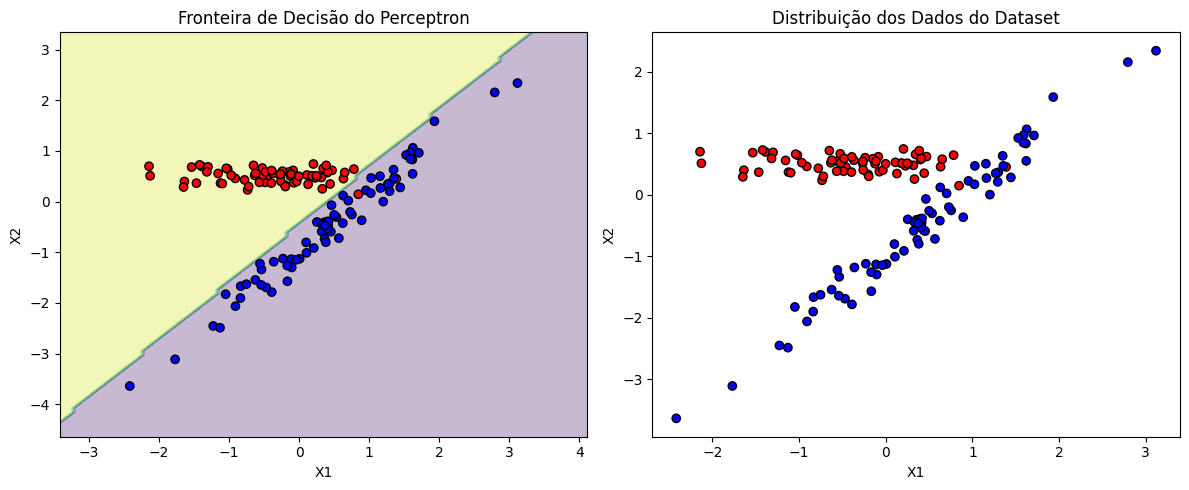

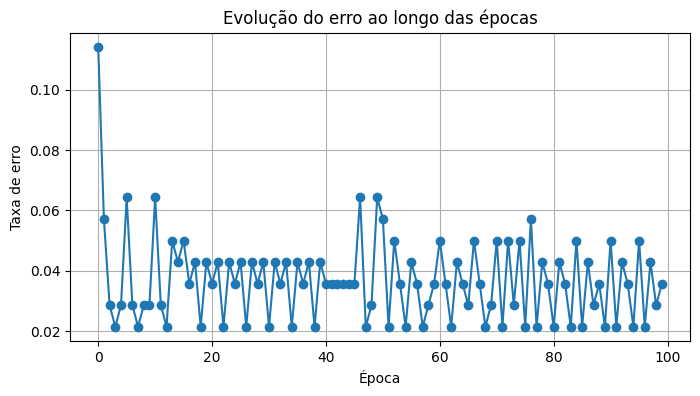

In [ ]:
# Dataset 1 - Importando e visualizando o dataset de TREINO
train_dataset1 = np.loadtxt('datasets/train_dataset1.csv',
                            delimiter=',', skiprows=1, dtype=float)

# Definição das entradas
X = train_dataset1[:, :2] # As duas primeiras colunas são os atributos (X1 e X2)
y = train_dataset1[:, 2] # Terceira coluna (rótulos)

# Converter rótulos para -1 e 1 (caso estejam diferentes)
y = np.where(y == -1, -1, 1)

# Criação do Perceptron e definição da taxa de aprendizado como 0.1 e número de eṕocas em 100
perceptron = Perceptron(learning_rate=0.1, n_epochs=100)

# Treinamento do Perceptron
perceptron.fit(X, y)

# Fazer previsões
plot_comparison(X, y, perceptron)
perceptron.plot_error()


# 1.2. Testando Dataset 1

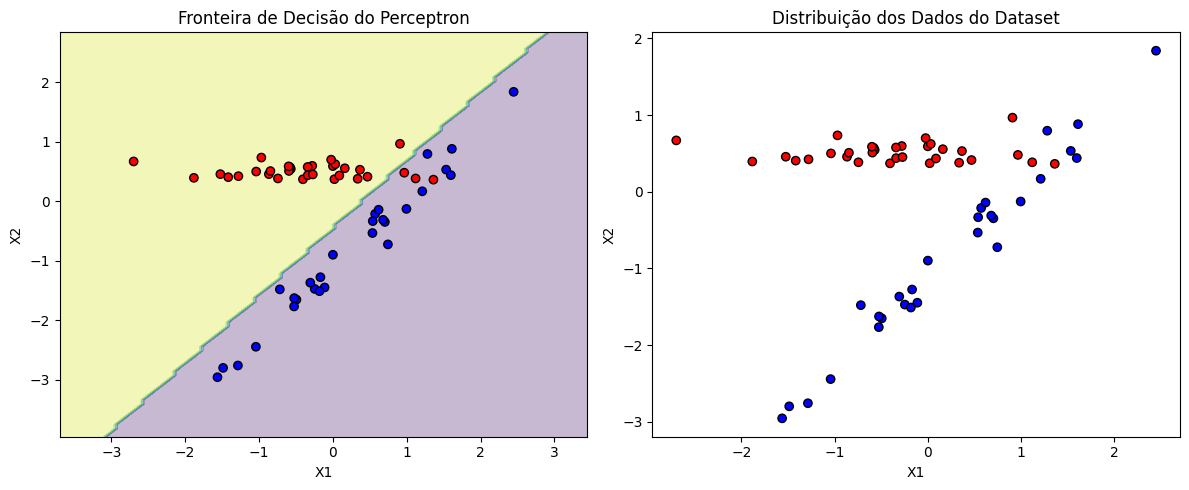

In [ ]:
# Tesntando o Perceptron com os dados do Dataset1
# Dataset 1 - importando e visualizando o dataset de Teste
test_dataset1 = np.loadtxt('datasets/test_dataset1.csv',
                            delimiter=',', skiprows=1, dtype=float)

# Separar entradas (X1, X2) e rotulos (label) do dataset de teste
X_test = test_dataset1[:, :2] # As duas primeiras colunas são os atributos (X1 e X2)
y_test = test_dataset1[:, 2] # Terceira coluna (rótulos)
y_test = np.where(y_test == -1, -1, 1) # Converter rótulos para -1 e 1 (caso estejam diferentes)

y_pred = perceptron.predict(X_test)

# Fazer previsões
plot_comparison(X_test, y_test, perceptron)

# 2.1 Treinando Dataset 2


===== Resumo do Treinamento ====
Acurácia no conjunto de treino: 47.43%
Número total de épocas: 100
Pesos finais aprendidos: [ 0.06747124 -0.08524414]
Bias final: 0.0



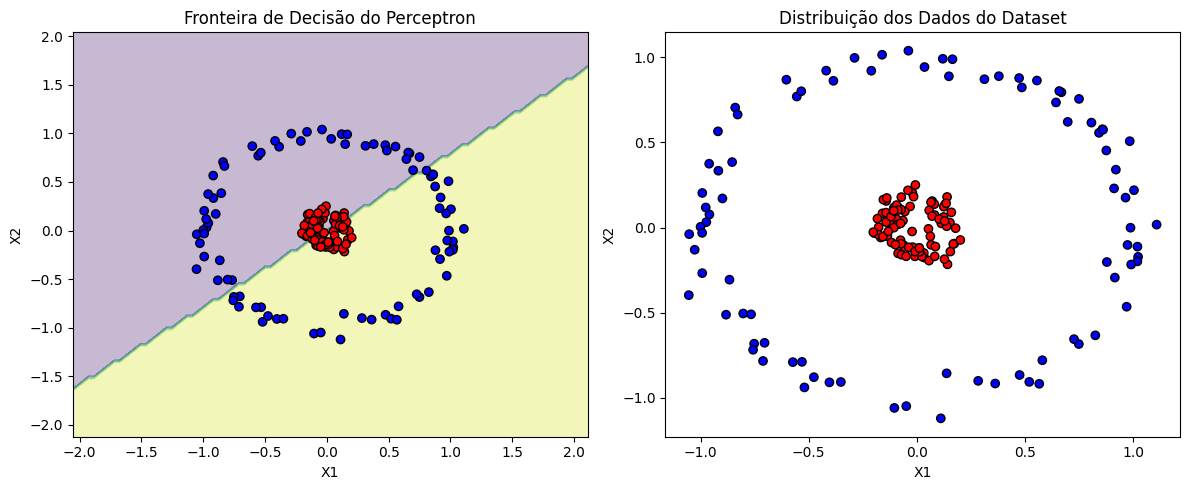

In [ ]:
# Dataset 2 - Importando e visualizando o dataset de TREINO
train_dataset2 = np.loadtxt('datasets/train_dataset2.csv',
                            delimiter=',', skiprows=1, dtype=float)

# Definição das entradas
X = train_dataset2[:, :2] # As duas primeiras colunas são os atributos (X1 e X2)
y = train_dataset2[:, 2] # Terceira coluna (rótulos)

# Converter rótulos para -1 e 1 (caso estejam diferentes)
y = np.where(y == -1, -1, 1)

# Criação do Perceptron e definição da taxa de aprendizado como 0.1 e número de eṕocas em 100
perceptron = Perceptron(learning_rate=0.1, n_epochs=100)

# Treinamento do Perceptron
perceptron.fit(X, y)

# Fazer previsões
plot_comparison(X, y, perceptron)


# 2.2 Treinando Dataset 2


 ========== Resumo do Teste =========
Acurácia no conjunto de teste: 49.33%
Desvio Padrão dos Pesos: 0.07636
Pesos finais aprendidos: [ 0.06747124 -0.08524414]
Bias final: 0.0



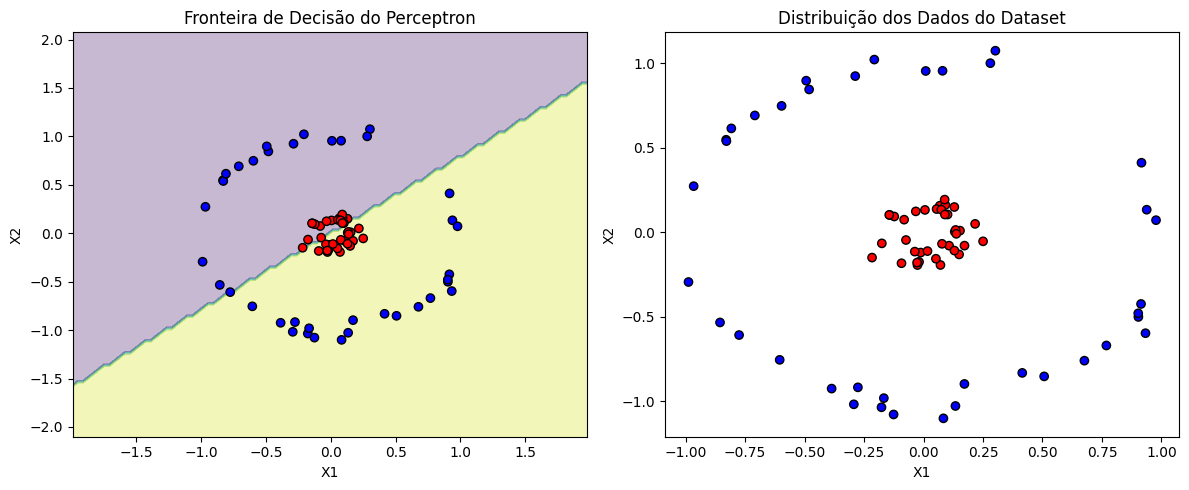

In [ ]:
# Tesntando o Perceptron com os dados do Dataset2
# Dataset 2 - importando e visualizando o dataset de Teste
test_dataset2 = np.loadtxt('datasets/test_dataset2.csv',
                            delimiter=',', skiprows=1, dtype=float)

# Separar entradas (X1, X2) e rotulos (label) do dataset de teste
X_test = test_dataset2[:, :2] # As duas primeiras colunas são os atributos (X1 e X2)
y_test = test_dataset2[:, 2] # Terceira coluna (rótulos)
y_test = np.where(y_test == -1, -1, 1) # Converter rótulos para -1 e 1 (caso estejam diferentes)

perceptron.predict2(X_test, y, y_test)

# Fazer previsões
plot_comparison(X_test, y_test, perceptron)

### Conclusão prática

> O Perceptron falhou no dataset acima, isso não é bug do código, é uma limitação teórica do algoritmo.

O Perceptron só converge e performa bem quando os dados são **linearmente separáveis**. Para esse tipo de distribuição circular, precisaria de algoritmos mais sofisticados, como:
- SVM com kernel RBF — cria fronteiras curvas
- Redes Neurais Multicamadas (MLP) — combina múltiplos perceptrons
- KNN ou árvores de decisão — não assumem separação linear

Esse resultado é inclusive um exemplo clássico usado para demonstrar a limitação do Perceptron — foi justamente esse tipo de problema que motivou o desenvolvimento de redes neurais mais profundas nos anos 60-70.

--- 

# 3.1 Treinando Dataset 3
### Dataset 3 - Importando e visualizando o dataset de TREINO
NOTA: dataset3 possui 10 features (x1..x10)

In [ ]:
# Dataset 3 - Importando e visualizando o dataset de TREINO

test_dataset3 = np.loadtxt('datasets/test_dataset3.csv',
                            delimiter=',', skiprows=1, dtype=float)

# Separar entradas (X1, X2) e rotulos (label) do dataset de teste
X_train3 = test_dataset3[:, :-1] # As duas primeiras colunas são os atributos (X1 e X2)
y_train3 = test_dataset3[:, -1] # Terceira coluna (rótulos)
y_train3 = np.where(y_train3 == -1, -1, 1) # Converter rótulos para -1 e 1 (caso estejam diferentes)

print(f"Shape do dataset de treino 3: {X_train3.shape}")

# Criação dos 6 Perceptrons conforme os cenários da tabela
cenarios = [
    {'learning_rate': 0.1,    'n_epochs': 100},
    {'learning_rate': 0.1,    'n_epochs': 200},
    {'learning_rate': 0.001,  'n_epochs': 100},
    {'learning_rate': 0.001,  'n_epochs': 200},
    {'learning_rate': 0.0001, 'n_epochs': 100},
    {'learning_rate': 0.0001, 'n_epochs': 200},
]

perceptrons_ds3 = []
for i, cfg in enumerate(cenarios, 1):
    print(f"\n--- Cenário {i}: lr={cfg['learning_rate']}, epochs={cfg['n_epochs']} ---")
    p = Perceptron(learning_rate=cfg['learning_rate'], n_epochs=cfg['n_epochs'])
    p.fit(X_train3, y_train3)
    perceptrons_ds3.append(p)



# 3.2 Treinando Dataset 3

In [ ]:
# Dataset 3 - Importando e visualizando o dataset de TESTE
test_dataset3 = np.loadtxt('datasets/test_dataset3.csv',
                             delimiter=',', skiprows=1, dtype=float)

X_test3 = test_dataset3[:, :-1]
y_test3 = test_dataset3[:, -1]
y_test3 = np.where(y_test3 == -1, -1, 1)

print(f"Shape do dataset de teste 3: {X_test3.shape}")

# Testando cada cenário com o conjunto de teste
resultados = []
for i, p in enumerate(perceptrons_ds3, 1):
    cfg = cenarios[i - 1]
    print(f"\n--- Cenário {i}: lr={cfg['learning_rate']}, epochs={cfg['n_epochs']} ---")
    p.predict_summary(X_test3, y_test3, 0, "Teste")
    y_pred = p.predict(X_test3)
    acc = np.mean(y_pred == y_test3) * 100
    resultados.append({'Cenário': i,
                        'Learning Rate': cfg['learning_rate'],
                        'Épocas': cfg['n_epochs'],
                        'Acurácia Teste (%)': round(acc, 2)})

# Tabela comparativa dos cenários
print("\n====== Tabela Comparativa dos Cenários - Dataset 3 ======")
print(f"{'Cenário':>8} | {'Learning Rate':>14} | {'Épocas':>7} | {'Acurácia Teste (%)':>18}")
print("-" * 60)
for r in resultados:
    print(f"{r['Cenário']:>8} | {r['Learning Rate']:>14} | {r['Épocas']:>7} | {r['Acurácia Teste (%)']:>18}")


Shape do dataset de teste 3: (63, 10)

--- Cenário 1: lr=0.1, epochs=100 ---

 ========== Resumo do Teste =========
Acurácia no conjunto de teste: 93.65%
Desvio Padrão dos Pesos: 0.30947
Pesos finais aprendidos: [ 0.0896773   0.15001225 -0.36735285 -0.00804984  0.29549006 -0.2421014
 -0.37140269 -0.02979643 -0.22666677  0.67538317]
Bias final: 0.20000000000000004


--- Cenário 2: lr=0.1, epochs=200 ---

 ========== Resumo do Teste =========
Acurácia no conjunto de teste: 92.06%
Desvio Padrão dos Pesos: 0.32165
Pesos finais aprendidos: [ 0.11269665  0.20580308 -0.19983055  0.2733262   0.0196717  -0.14929332
 -0.08362276  0.10152119 -0.31242919  0.89544706]
Bias final: 0.10000000000000003


--- Cenário 3: lr=0.001, epochs=100 ---

 ========== Resumo do Teste =========
Acurácia no conjunto de teste: 87.30%
Desvio Padrão dos Pesos: 0.19626
Pesos finais aprendidos: [ 0.11633456  0.20384506 -0.08160417 -0.04015689  0.1553301   0.01743626
  0.21751665  0.06000121 -0.19101424  0.55995601]
Bias

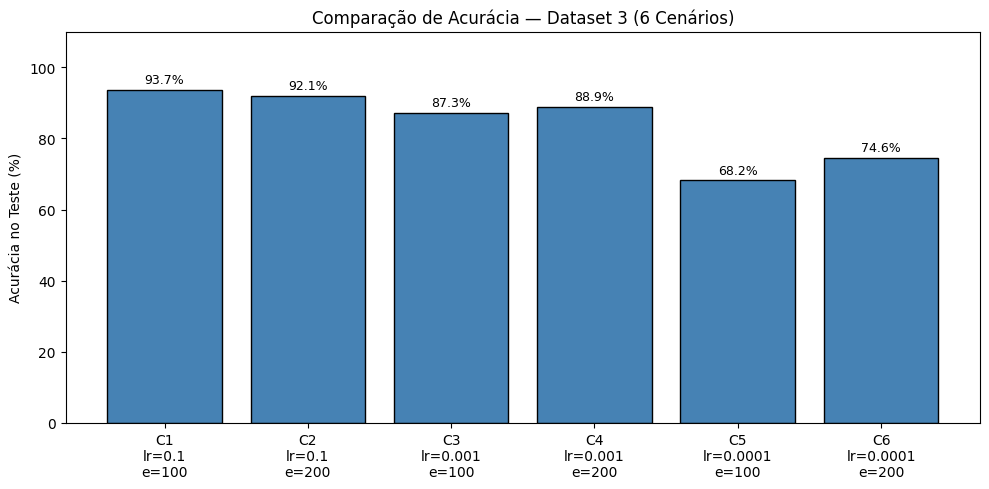

In [ ]:
# Gráfico comparativo de acurácia entre os 6 cenários - Dataset 3
labels = [f"C{r['Cenário']}\nlr={r['Learning Rate']}\ne={r['Épocas']}" for r in resultados]
acuracias = [r['Acurácia Teste (%)'] for r in resultados]

plt.figure(figsize=(10, 5))
bars = plt.bar(labels, acuracias, color='steelblue', edgecolor='k')
plt.ylim(0, 110)
plt.ylabel("Acurácia no Teste (%)")
plt.title("Comparação de Acurácia — Dataset 3 (6 Cenários)")
for bar, val in zip(bars, acuracias):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
             f"{val:.1f}%", ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()


In [ ]:
# Evolução do erro por época para cada cenário do Dataset 3
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, (p, cfg) in enumerate(zip(perceptrons_ds3, cenarios)):
    axes[i].plot(p.errors_per_epoch, marker='o', markersize=3, linestyle='-')
    axes[i].set_title(f"Cenário {i+1}: lr={cfg['learning_rate']}, epochs={cfg['n_epochs']}")
    axes[i].set_xlabel("Época")
    axes[i].set_ylabel("Taxa de Erro")
    axes[i].grid(True)

plt.suptitle("Evolução do Erro — Dataset 3 (6 Cenários)", fontsize=13)
plt.tight_layout()
plt.show()


## Como interpretar os resultados do seu notebook especificamente
 - Datasets 1 e 2 — têm apenas 2 features (x1, x2), então a fronteira de decisão é literalmente uma linha num plano. Você consegue ver visualmente se o perceptron acertou ou não.
 - Dataset 3 — tem 10 features, então não dá para visualizar a fronteira diretamente. O que importa aqui é a tabela comparativa e os gráficos de erro. Os 6 cenários variam dois hiperparâmetros:

`learning_rate` — o tamanho do passo de ajuste dos pesos. Valores muito altos podem fazer o algoritmo "pular" a solução; muito baixos convergem devagar.
`n_epochs` — quantas vezes o algoritmo percorre o dataset inteiro. Mais épocas dão mais chances de convergir, mas se os dados não forem separáveis, não adianta.

#### A leitura esperada dos cenários é algo assim:
| Cenário | O que tende a acontecer |
| :--- | :--- |
| **lr alto + poucas épocas** | Aprende rápido, mas pode não refinar bem |
| **lr alto + muitas épocas** | Pode oscilar se os dados forem difíceis |
| **lr baixo + poucas épocas** | Pode não convergir a tempo |
| **lr baixo + muitas épocas** | Geralmente o mais estável e preciso |

O cenário com maior acurácia no teste é o que melhor generalizou — ou seja, não só decorou o treino, mas aprendeu a classificar dados novos corretamente.

Se quiser, posso rodar o notebook aqui e te mostrar os resultados numéricos e gráficos reais dos seus dados!